<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#1---File-formats---JPG,-PNG,-PDF-&amp;-Extent" data-toc-modified-id="1---File-formats---JPG,-PNG,-PDF-&amp;-Extent-1">1 - File formats - JPG, PNG, PDF &amp; Extent</a></span><ul class="toc-item"><li><span><a href="#JPG" data-toc-modified-id="JPG-1.1">JPG</a></span></li><li><span><a href="#PNG32" data-toc-modified-id="PNG32-1.2">PNG32</a></span></li><li><span><a href="#PDF" data-toc-modified-id="PDF-1.3">PDF</a></span></li></ul></li><li><span><a href="#2-Change-DPI" data-toc-modified-id="2-Change-DPI-2">2 Change DPI</a></span></li><li><span><a href="#3-Change-map-image-dimensions" data-toc-modified-id="3-Change-map-image-dimensions-3">3 Change map image dimensions</a></span></li><li><span><a href="#4.-Change-map-scale" data-toc-modified-id="4.-Change-map-scale-4">4. Change map scale</a></span></li><li><span><a href="#5.-Rotation" data-toc-modified-id="5.-Rotation-5">5. Rotation</a></span></li><li><span><a href="#6.-Layouts---A4,-Letter" data-toc-modified-id="6.-Layouts---A4,-Letter-6">6. Layouts - A4, Letter</a></span></li><li><span><a href="#7.-Complex-map" data-toc-modified-id="7.-Complex-map-7">7. Complex map</a></span></li><li><span><a href="#Download-image-file" data-toc-modified-id="Download-image-file-8">Download image file</a></span></li></ul></div>

# Test WebMap.print() function

In [ ]:
# When using `geosaurus_dev_env` conda env

# import sys
# sys.path.append('/Users/atma6951/Documents/code/geosurus/geosaurus/src')

In [40]:
from arcgis.gis import GIS
from arcgis.mapping import WebMap, export_map, get_layout_templates
from arcgis.geometry import Point
from arcgis.features import FeatureSet, FeatureCollection, Feature
from arcgis.geocoding import geocode

import json
import requests
from IPython.display import Image
import matplotlib.pyplot as plt

import time, os
import requests
%matplotlib inline

In [6]:
import arcgis
print(arcgis.__version__)

2.0.0


In [70]:
gis = GIS('https://pythonapi.playground.esri.com/portal')

In [71]:
pt1 = Point([-117.18, 34.05])
ft = Feature(pt1, attributes={'name':'Redlands'})
fset = FeatureSet([ft])
fc = FeatureCollection.from_featureset(fset)
fc

<FeatureCollection>

In [72]:
redlands_extent = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'xmin': -13074746.000753032,
 'ymin': 4020957.451106308,
 'xmax': -13014666.49652086,
 'ymax': 4051532.26242039}

ca_extent = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'xmin': -15199645.40582486,
 'ymin': 3395607.5273594954,
 'xmax': -11354557.134968376,
 'ymax': 5352395.451459487}

In [ ]:
map2 = gis.map('California')
map2

In [8]:
map2.extent

{'xmin': -124.20822999999997,
 'ymin': 31.436105693000048,
 'xmax': -114.33222999999997,
 'ymax': 41.31210569300005}

In [9]:
map2.scale

-1.0

In [10]:
map2.rotation

0.0

## 1 - File formats - JPG, PNG, PDF & Extent

In [74]:
wm1 = WebMap()
wm1.basemap = 'streets-vector'

KeyError: 'defaultBasemap'

In [19]:
wm1.add_layer(fc)

True

### JPG

In [75]:
%%time
print_jpg = wm1.print(file_format='JPG', extent=redlands_extent)
print_jpg

CPU times: user 7.33 ms, sys: 2.21 ms, total: 9.54 ms
Wall time: 2.65 s


'https://pythonapi.playground.esri.com/server/rest/directories/arcgisoutput/Utilities/PrintingTools_GPServer/_ags_67770e62-7a8e-11ec-8d99-06420ad1e528.jpg'

In [76]:
Image(url=print_jpg)

### PNG32

In [21]:
time.sleep(30)

In [77]:
%%time
print_png = wm1.print(file_format='PNG32', extent=redlands_extent)

CPU times: user 9.89 ms, sys: 2.72 ms, total: 12.6 ms
Wall time: 2.01 s


In [78]:
Image(url=print_png)

In [45]:
if os.path.isfile(print_png):
    fig, ax = plt.subplots(1,2, figsize=(15,10))
    ppng = plt.imread(print_png)
    ax[0].imshow(ppng)
    ax[0].set_title('PNG');

if os.path.isfile(print_jpg):
    pjpg = plt.imread(print_jpg, format='JPG')
    ax[1].imshow(pjpg)
    ax[1].set_title('JPG');


### PDF

In [ ]:
time.sleep(30)

In [79]:
%%time
print_pdf = wm1.print(file_format='PDF', extent=ca_extent)

CPU times: user 8.92 ms, sys: 2.52 ms, total: 11.4 ms
Wall time: 3.11 s


In [80]:
from IPython.display import display_pdf
r=requests.get(print_pdf)


In [81]:
display_pdf(r.content, raw=True)

## 2 Change DPI

In [ ]:
time.sleep(30)

In [82]:
%%time
print_150dpi = wm1.print(file_format='JPG', extent=ca_extent, dpi=150)
print_300dpi = wm1.print(file_format='JPG', extent=ca_extent, dpi=300)

CPU times: user 18.5 ms, sys: 3.86 ms, total: 22.4 ms
Wall time: 3.54 s


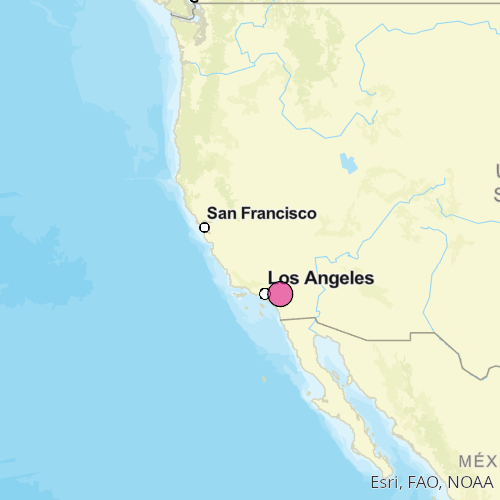

In [83]:
Image(print_150dpi)

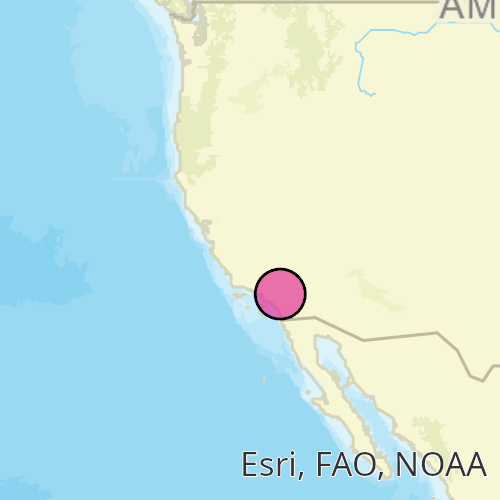

In [84]:
Image(print_300dpi)

In [33]:
if os.path.isfile(print_150dpi):
    fig, ax = plt.subplots(1,2, figsize=(15,10))
    p1 = plt.imread(print_150dpi, format='JPG')
    ax[0].imshow(p1)
    ax[0].set_title('150 DPI');
if os.path.isfile(print_300dpi):
    p1 = plt.imread(print_300dpi, format='JPG')
    ax[1].imshow(p1)
    ax[1].set_title('300 DPI')

## 3 Change map image dimensions

In [ ]:
time.sleep(30)

In [85]:
%%time
print_300x300 = wm1.print(file_format='JPG', 
                          extent=ca_extent, output_dimensions=[300,300])
print_600x400 = wm1.print(file_format='JPG', 
                          extent=ca_extent, output_dimensions=[600,400])

CPU times: user 18.3 ms, sys: 3.61 ms, total: 21.9 ms
Wall time: 3.32 s


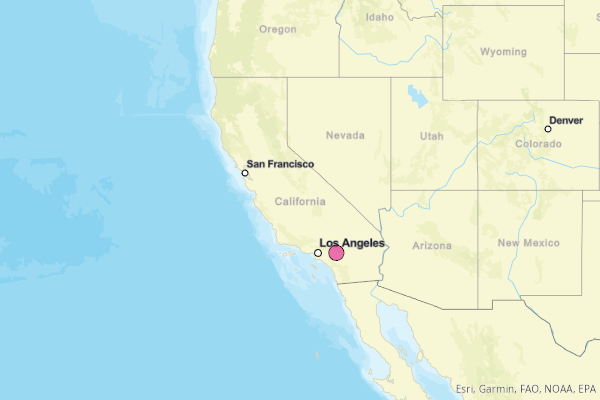

In [86]:
Image(print_600x400)

In [ ]:
if os.path.isfile(print_300x300):
    fig, ax = plt.subplots(1,2, figsize=(15,10))
    p1 = plt.imread(print_300x300, format='JPG')
    ax[0].imshow(p1)
    ax[0].set_title('300 x 300');
if os.path.isfile(print_600x400):
    p1 = plt.imread(print_600x400, format='JPG')
    ax[1].imshow(p1)
    ax[1].set_title('600 x 400');

## 4. Change map scale

In [ ]:
time.sleep(30)

In [87]:
%%time
print_36k = wm1.print(file_format='JPG', 
                          extent=redlands_extent, scale=36000)

print_150k = wm1.print(file_format='JPG', 
                          extent=redlands_extent, scale=150000)

CPU times: user 18.8 ms, sys: 3.47 ms, total: 22.2 ms
Wall time: 5.3 s


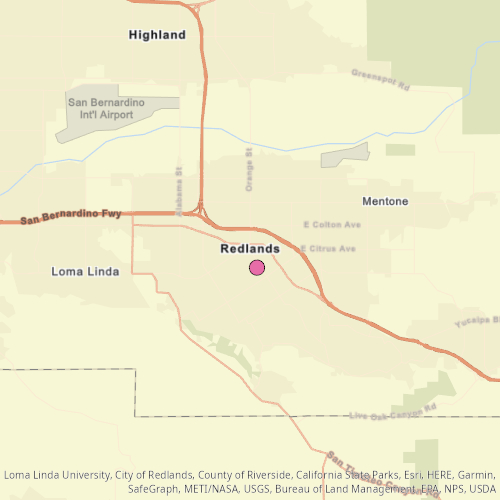

In [88]:
Image(print_150k)

In [89]:
if os.path.isfile(print_36k):
    fig, ax = plt.subplots(1,2, figsize=(15,10))
    p1 = plt.imread(print_36k, format='JPG')
    ax[0].imshow(p1)
    ax[0].set_title('Scale 1:36,000');

if os.path.isfile(print_150k):
    p1 = plt.imread(print_150k, format='JPG')
    ax[1].imshow(p1)
    ax[1].set_title('Scale 1:150,000');

## 5. Rotation

In [ ]:
# %%time
# print_90e = wm1.print(file_format='JPG', 
#                           extent=redlands_extent, rotation=90)

# print_180s = wm1.print(file_format='JPG', 
#                           extent=redlands_extent, rotation=180)

In [ ]:
# fig, ax = plt.subplots(1,2, figsize=(15,10))
# p1 = plt.imread(print_90e, format='JPG')
# ax[0].imshow(p1)
# ax[0].set_title('Rotation: 90 deg');

# p1 = plt.imread(print_180s, format='JPG')
# ax[1].imshow(p1)
# ax[1].set_title('Rotation: 180 deg');

## 6. Layouts - A4, Letter

In [ ]:
time.sleep(30)

In [90]:
[i['layoutTemplate'] for i  in get_layout_templates()]

['A3 Landscape',
 'A3 Portrait',
 'A4 Landscape',
 'A4 Portrait',
 'Letter ANSI A Landscape',
 'Letter ANSI A Portrait',
 'Tabloid ANSI B Landscape',
 'Tabloid ANSI B Portrait']

In [ ]:
time.sleep(30)

In [91]:
%%time
print_a4land = wm1.print(file_format='JPG', 
                          extent=redlands_extent, layout_template='A4 Landscape')

print_let_port = wm1.print(file_format='JPG', 
                          extent=redlands_extent, layout_template='Letter ANSI A Portrait')

CPU times: user 16.2 ms, sys: 3.97 ms, total: 20.2 ms
Wall time: 5.73 s


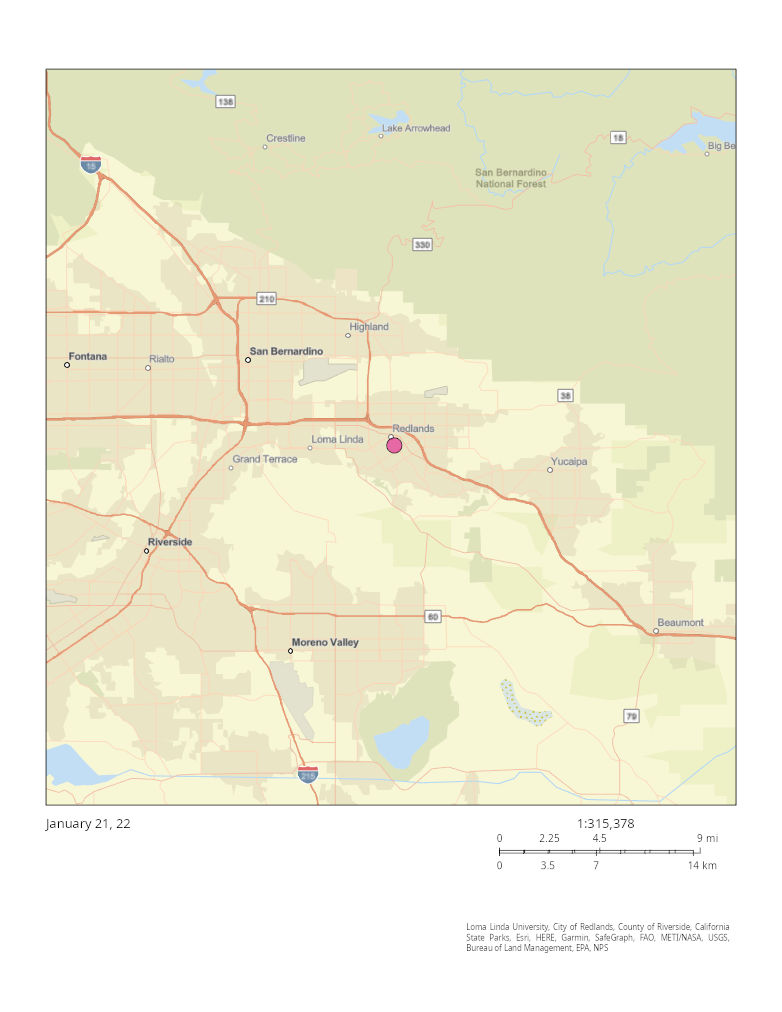

In [92]:
Image(print_let_port)

In [ ]:
if os.path.isfile(print_a4land):
    fig, ax = plt.subplots(1,2, figsize=(15,10))
    p1 = plt.imread(print_a4land, format='JPG')
    ax[0].imshow(p1)
    ax[0].set_title('Layout: A4 Landscape');
if os.path.isfile(print_let_port):
    p1 = plt.imread(print_let_port, format='JPG')
    ax[1].imshow(p1)
    ax[1].set_title('Layout: Letter Portrait');

## 7. Complex map

In [ ]:
time.sleep(30)

In [93]:
wm_item = gis.content.get('c6ba9c02006948b9bdc1d66436fa5d29')
complex_wm = WebMap(wm_item)

KeyError: 'defaultBasemap'

In [ ]:
%%time
print_a4land_c = complex_wm.print(file_format='JPG', 
                          extent=ca_extent, layout_template='A4 Landscape')

In [ ]:
if os.path.isfile(print_a4land_c):
    Image(print_a4land_c)

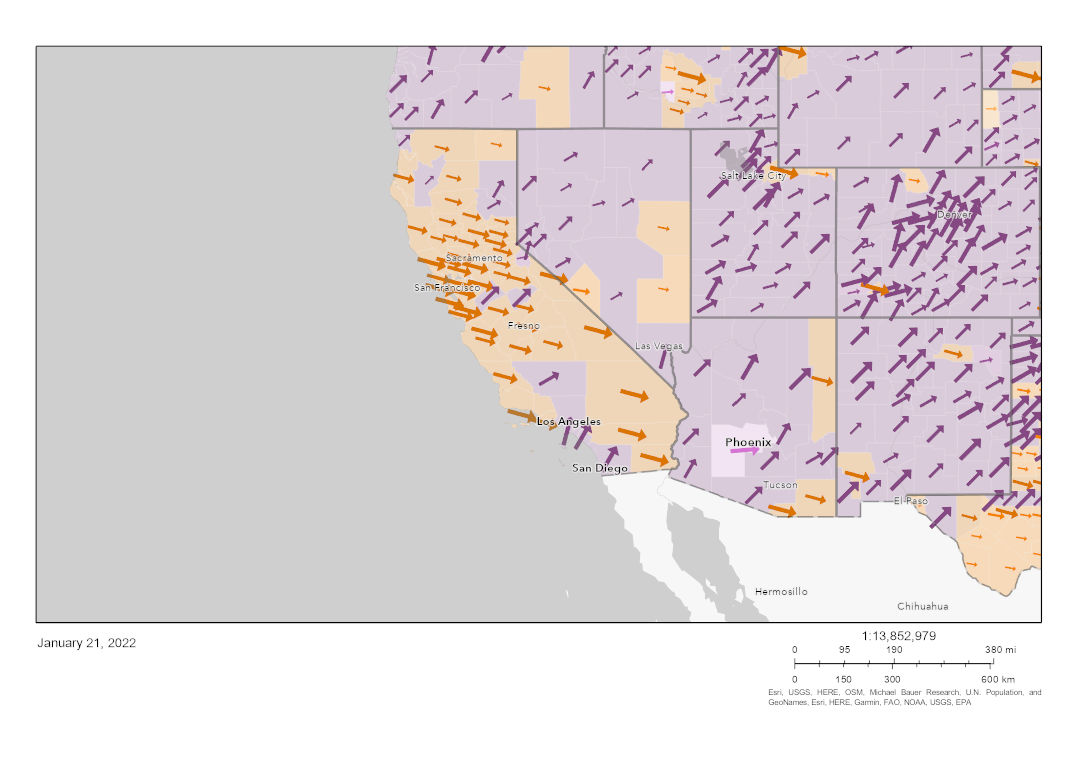

In [68]:
Image(print_a4land_c)

## Download image file

In [ ]:
import requests

In [ ]:
with requests.get(print_png) as resp:
    with open('./output_file.png', 'wb') as file_handle:
        file_handle.write(resp.content)